Score-based Generative Modeling 

In [1]:
import sys
from torch.utils.data.dataloader import DataLoader
import torch
from torch import nn
from torch import tensor
import torch.nn.functional as F
import matplotlib.pyplot as plt
sys.path.append("../..")
from datasets.gaussian_spiral import GaussianSpiralDataset, plot_gaussian_spiral
from datasets.digits import Digits, plot_digits

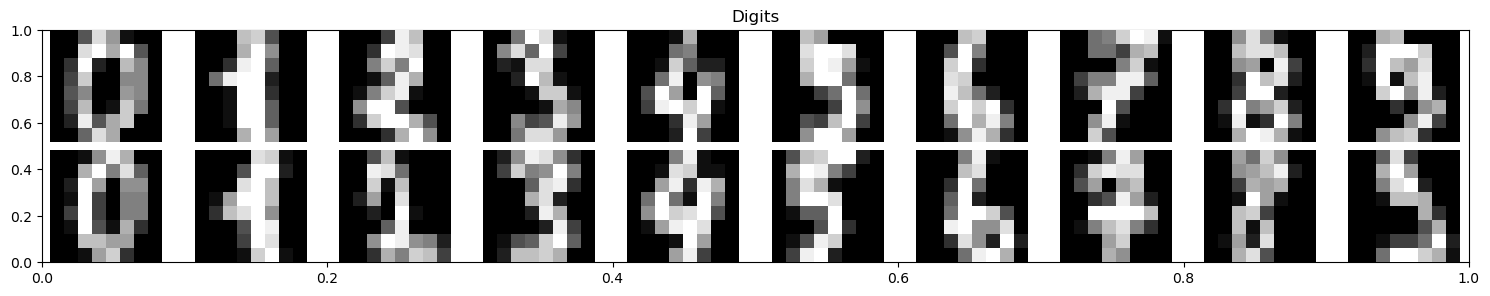

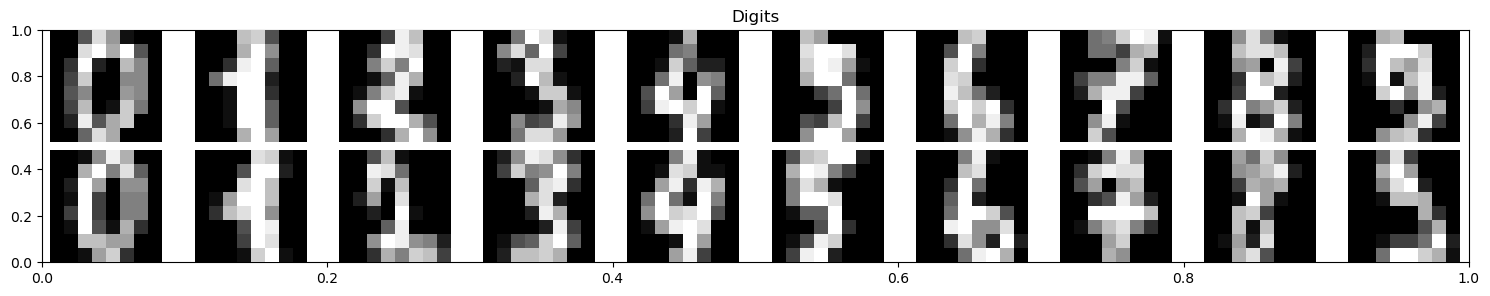

In [2]:
# n=1000
# train_dataset = GaussianSpiralDataset(n=n, rotations=2, var=0.2, seed=None, mode="train", mean=None, std=None)
# train_dataloader = DataLoader(dataset=train_dataset, batch_size=n)
# plot_gaussian_spiral(*next(iter(train_dataloader)))

n=20
train_dataset = Digits(mode="train", normalized=True)
train_dataloader = DataLoader(dataset=train_dataset, batch_size=n)
plot_digits(next(iter(train_dataloader)))


### Score Network

In [3]:
def sigmas_geometric(t, sigma_min=0.0, sigma_max=1.0, type='ncsn'):
    # uniform in [0,1]
    sigma_min, sigma_max = tensor(sigma_min), tensor(sigma_max)
    t = tensor(t)

    if type == 'ncsn':        
        log_sigma = torch.log(sigma_min) + t * (torch.log(sigma_max) - torch.log(sigma_min))
        return torch.exp(log_sigma)
    if type == 'VE-SDE':
        assert sigma_min==0.0
        return torch.sqrt( (1./(2.* torch.log(sigma_max))) * (sigma_max**(2*t) - 1.) )
    if type == 'lin':
        return sigma_min + (sigma_max - sigma_min) * t
    


class ScoreNet(nn.Module):

    def __init__(self, dim, hidden_dims=[8,8]):
        super().__init__()

        dims = [dim]+hidden_dims
        self.time_embedding = nn.Sequential(nn.Linear(1, dim), nn.Tanh())
        
        layers = []
        for in_d, out_d in zip(dims[:-1], dims[1:]):
            layers.append(nn.Linear(in_d, out_d))
            layers.append(nn.ReLU())
            
        self.layers = nn.Sequential(*layers)

        self.out = nn.Linear(hidden_dims[-1], dim)
        
    def forward(self, x, sigmas):

        x = x + self.time_embedding(sigmas)
        x = self.layers(x)
        x = self.out(x)

        return x


class ScoreNetT(nn.Module):
    def __init__(self, dim, hidden_dims=[32,32]):
        super().__init__()
        dims = [dim] + hidden_dims

        # one embedding per layer input
        self.t_embs = nn.ModuleList([
            nn.Sequential(nn.Linear(1, in_d), nn.Tanh())
            for in_d in dims
        ])

        self.layers = nn.ModuleList([
            nn.Linear(in_d, out_d)
            for in_d, out_d in zip(dims, dims[1:])
        ])
        self.out = nn.Linear(hidden_dims[-1], dim)

    def forward(self, x, sigma):
        for t_emb, lin in zip(self.t_embs, self.layers):
            # inject σ at each layer
            x = F.relu(lin(x + t_emb(sigma)))
        return self.out(x)
    
class ScoreNetConv(nn.Module):
    def __init__(self, in_channels, hidden_channels=[32, 32]):
        super().__init__()
        channels = [in_channels] + hidden_channels

        self.t_embs = nn.ModuleList([
            nn.Sequential(nn.Linear(1, ch), nn.Tanh())
            for ch in channels
        ])

        self.convs = nn.ModuleList([
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
            for in_ch, out_ch in zip(channels, channels[1:])
        ])
        self.out = nn.Conv2d(hidden_channels[-1], in_channels, kernel_size=3, padding=1)

    def forward(self, x, sigma):
        
        assert len(x.shape) == 4, f"Expecting [B,C,H,W], but got len(x.shape)={len(x.shape)}"

        for t_emb, conv in zip(self.t_embs, self.convs):
            emb = t_emb(sigma.view(-1, 1)).view(-1,conv.in_channels,1,1)
            x = F.relu(conv(x + emb))
        return self.out(x)
    

class FiLMLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        # map time t→ [γ, β] of size 2*out_features
        self.film   = nn.Linear(1, 2 * out_features)

    def forward(self, x, t):
        # x: (B, in_features), t: (B,) or (B,1)
        h = self.linear(x)
        t = t.view(-1, 1)              # ensure shape (B,1)
        gamma, beta = self.film(t).chunk(2, dim=-1)
        return gamma * h + beta

class ScoreNetFiLM(nn.Module):

    def __init__(self, dim, hidden_dims=[8,8]):
        super().__init__()

        dims = [dim]+hidden_dims

        self.time_embedding = nn.Sequential(nn.Linear(1, dim), nn.Tanh())
        
        self.layers = nn.ModuleList([
            FiLMLinear(in_d, out_d)
            for in_d, out_d in zip(dims[:-1], dims[1:])
        ])

        self.out = nn.Linear(hidden_dims[-1], dim)
        
    def forward(self, x, sigmas):

        for layer in self.layers:
            x = F.relu(layer(x, sigmas))
        return self.out(x)


### Training and Validation Loops

In [4]:
def train_one_epoch(model, optimizer, dataloader, sigma_min, sigma_max, var_schedule, device):

    avg_loss = 0.0
    model.train()

    # for _, (x, _) in enumerate(dataloader):
    for _, x in enumerate(dataloader):
        # x.shape = [B,C or D, (optionally) H, W]

        # add noise
        sigmas =  sigmas_geometric(torch.rand([x.shape[0]] +[1]*len(x.shape[1:])), sigma_min, sigma_max, var_schedule).float()
        # sigmas =  sigmas_geometric(torch.rand((1,))* torch.ones(x.shape[0],1), sigma_min, sigma_max).float()
        # first overfit on single batch and single noise level
        # sigmas = sigmas_geometric(torch.ones(size=(batch_size,1)), sigma_min, sigma_max).float()

        noise = torch.randn_like(x)
        # noise = seeded_noise
        x_noisy = x + noise * sigmas

        sigmas, x_noisy, x = sigmas.to(device), x_noisy.to(device), x.to(device)
        nc_score = model(x_noisy, sigmas)

        denoising_loss = 0.5 * (nc_score + (x_noisy-x)/sigmas**2 )**2
        # unified loss by Song
        loss = (sigmas**2 * denoising_loss).mean() #+ model.parameters() # [B,1]*[B,D]--> [B,D]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item()
            
    return avg_loss / len(dataloader)

def validate(model, dataloader, epoch, sigma_min, sigma_max, var_schedule, device, plot_samples=None):

    # Disable gradient computation and reduce memory consumption.
    val_loss = 0.0
    model.eval()
    with torch.no_grad():

        # for x,_ in dataloader:
        for x in dataloader:

            sigmas = sigmas_geometric(torch.rand([x.shape[0]] +[1]*len(x.shape[1:])), sigma_min, sigma_max, var_schedule).float()
            noise = torch.randn_like(x)

            x_noisy = x + noise * sigmas

            if epoch == 0:
                plot_samples = x.shape[0] if plot_samples is None else plot_samples
                # plot_gaussian_spiral(x, t)
                # plot_gaussian_spiral(noise*sigmas)
                # plot_gaussian_spiral(x_noisy)
                
                plot_digits(x[:plot_samples], title="Raw Samples")
                plot_digits(noise[:plot_samples]*sigmas[:plot_samples], title="Noise")
                plot_digits(x_noisy[:plot_samples], title="Raw Samples with added Noise")

            sigmas, x_noisy, x = sigmas.to(device), x_noisy.to(device), x.to(device)
            nc_score = model(x_noisy, sigmas)

            denoising_loss = 0.5 * (nc_score + (x_noisy-x)/sigmas**2)**2
            # unified loss by Song
            val_loss += (sigmas**2 * denoising_loss).mean()

        return val_loss / len(dataloader)




### Training

NumParams: 150531


/tmp/ipykernel_3581768/1833020302.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = tensor(t)


Epoch 0, training loss: 0.8318846027056376


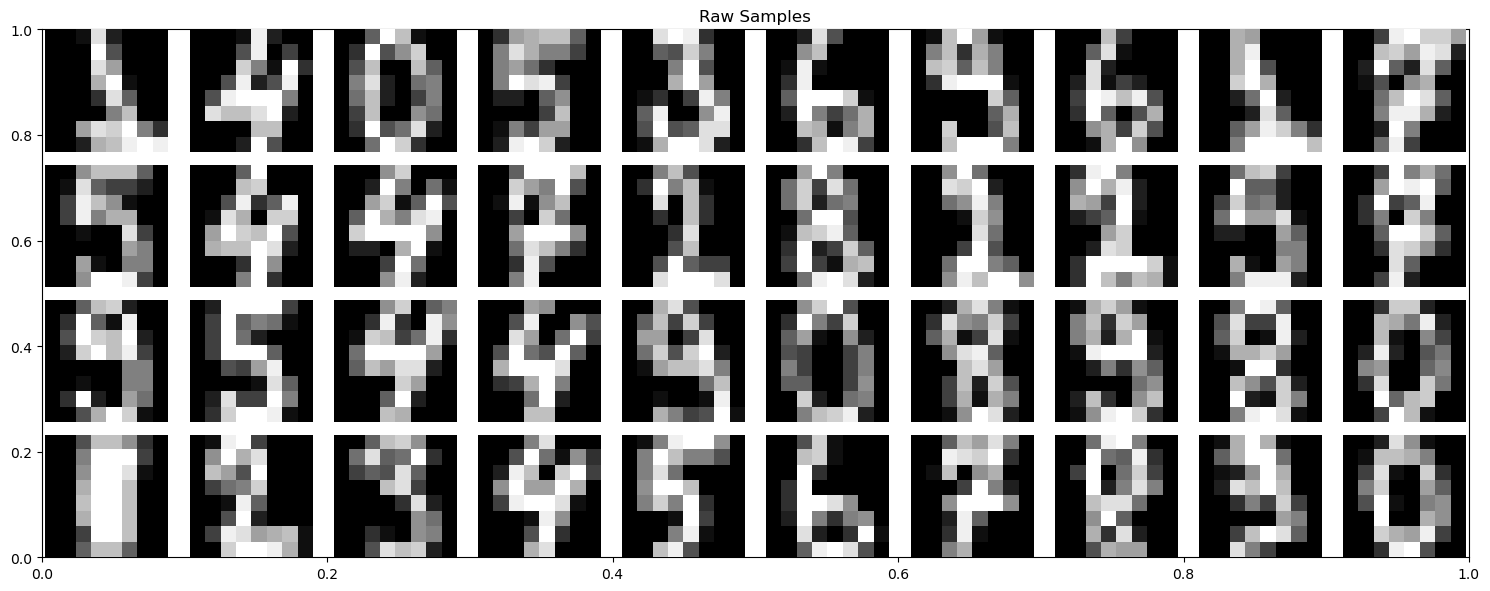

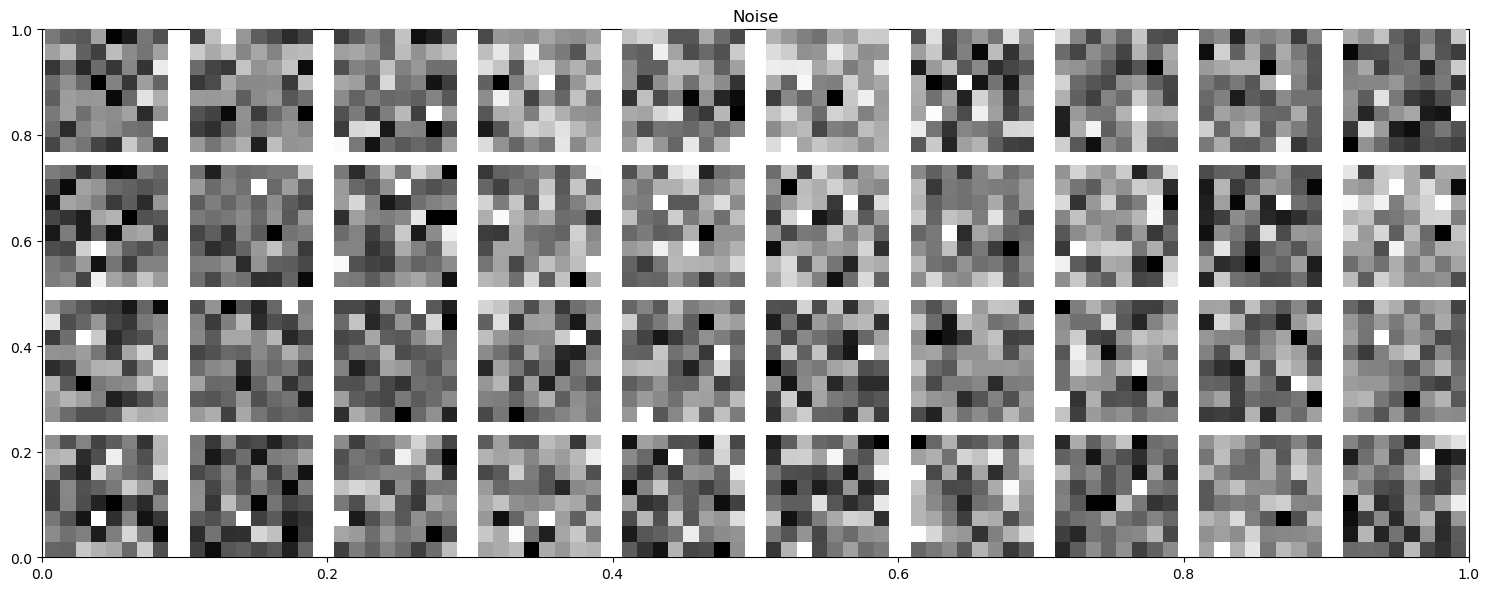

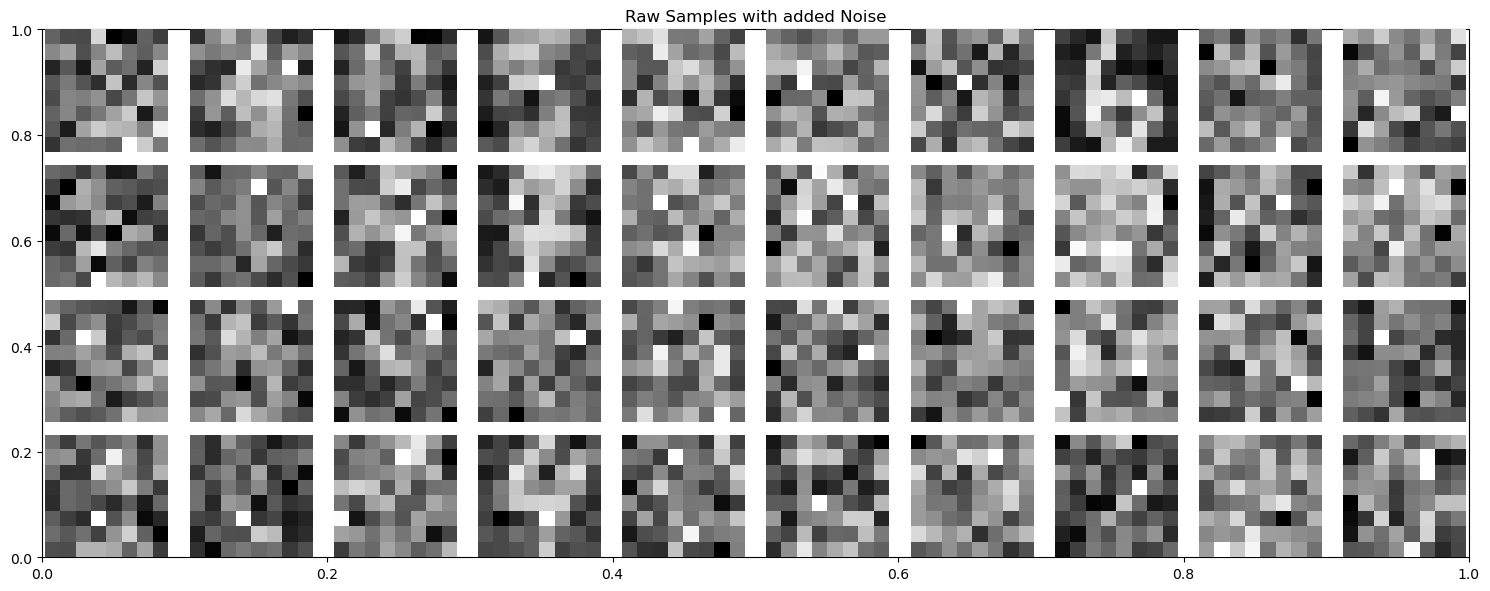

Epoch 0, training loss: 0.8318846027056376, validation loss: 0.7329777479171753
Epoch 1, training loss: 0.7016103665033976
Epoch 1, training loss: 0.7016103665033976, validation loss: 0.650463342666626
Epoch 2, training loss: 0.6164727807044983
Epoch 2, training loss: 0.6164727807044983, validation loss: 0.5709047913551331
Epoch 3, training loss: 0.5265706380208334
Epoch 3, training loss: 0.5265706380208334, validation loss: 0.5090437531471252
Epoch 4, training loss: 0.4858107070128123
Epoch 4, training loss: 0.4858107070128123, validation loss: 0.4480617046356201
Epoch 5, training loss: 0.45242610573768616
Epoch 5, training loss: 0.45242610573768616, validation loss: 0.4279996156692505
Epoch 6, training loss: 0.42954447865486145
Epoch 6, training loss: 0.42954447865486145, validation loss: 0.4068419933319092
Epoch 7, training loss: 0.40712249279022217
Epoch 7, training loss: 0.40712249279022217, validation loss: 0.40077248215675354
Epoch 8, training loss: 0.4046723246574402
Epoch 8, t

In [5]:
max_epochs = 1000
batch_size = 256
patience = 20

device = 0

var_schedule = 'lin'
sigma_min = 0.01
sigma_max = 5.0

learning_rate = 2e-5
spiral_var = 0.1
plot_samples = 40


# train_dataset = GaussianSpiralDataset(n=10000, rotations=2, var=spiral_var, seed=42, mode="train")
# train_dataloader = DataLoader(dataset=train_dataset, batch_size=batch_size, drop_last=True)
# val_dataset = GaussianSpiralDataset(n=2000, rotations=2, var=spiral_var, seed=43, mode="val", mean=train_dataset.get_mean(), std=train_dataset.get_std())
# val_dataloader = DataLoader(dataset=val_dataset, batch_size=len(val_dataset))

train_dataset = Digits(mode="train", normalized=True)
val_dataset = Digits(mode="val", normalized=True)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=len(val_dataset))


# ncsm = ScoreNetT(dim=2, hidden_dims=[32,32])
# ncsm = ScoreNetFiLM(dim=2, hidden_dims=[32,32])
ncsm = ScoreNetConv(in_channels=1, hidden_channels=[128,128])
ncsm = ncsm.to(device)

print(f"NumParams: {sum([p.numel() for p in ncsm.parameters()])}")

optimizer = torch.optim.AdamW(ncsm.parameters(), lr=learning_rate)
patience_count = 0
best_val_loss = torch.inf

for epoch in range(max_epochs):

    train_loss = train_one_epoch(ncsm, optimizer, train_dataloader, sigma_min, sigma_max, var_schedule, device)
    print(f"Epoch {epoch}, training loss: {train_loss}")

    val_loss = validate(ncsm, val_dataloader, epoch, sigma_min, sigma_max, var_schedule, device, plot_samples=plot_samples)
    print(f"Epoch {epoch}, training loss: {train_loss}, validation loss: {val_loss}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_count = 0
        torch.save(ncsm, 'ncsm.ckpt')
    else:
        patience_count += 1

    if patience_count >= patience:
        print(f"No improvement in {patience} epochs, stopping.")
        break

### Sampling

/tmp/ipykernel_3581768/1833020302.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = tensor(t)
/tmp/ipykernel_3581768/4278065524.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_on

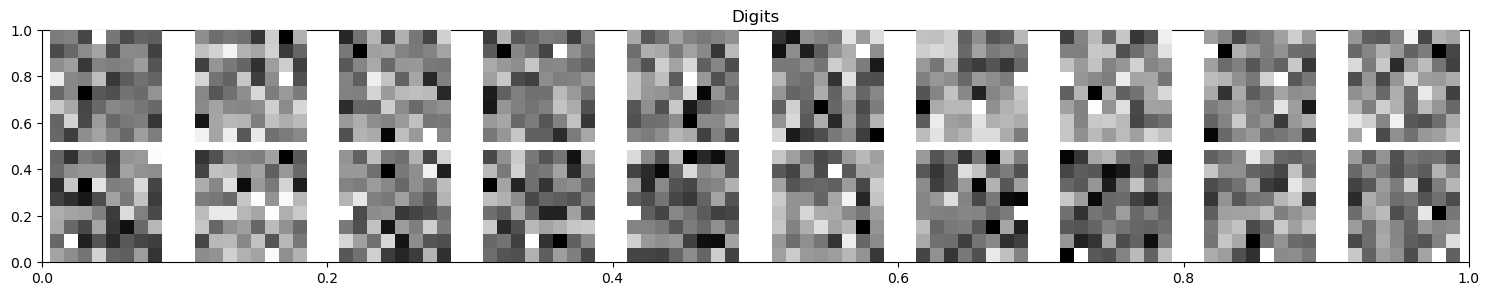

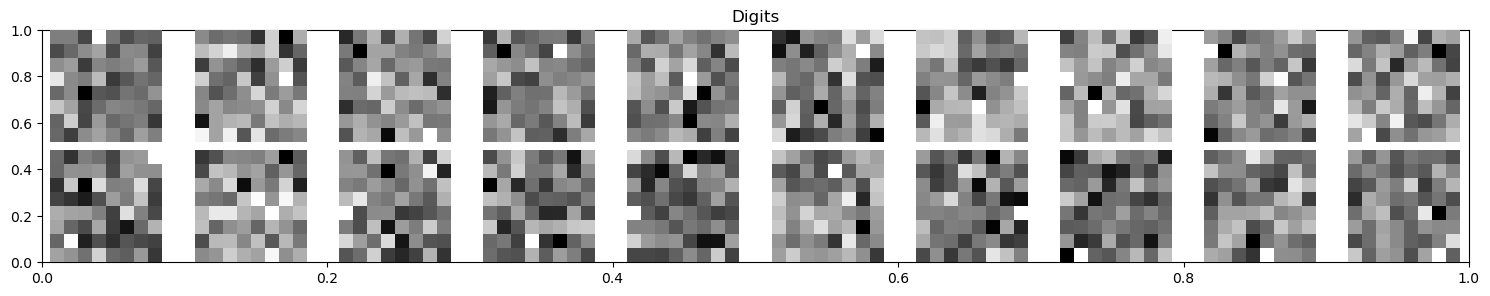

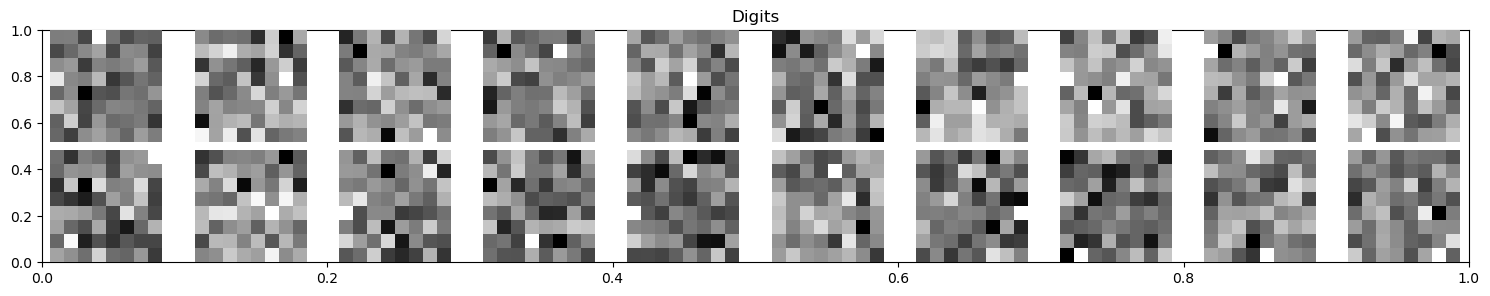

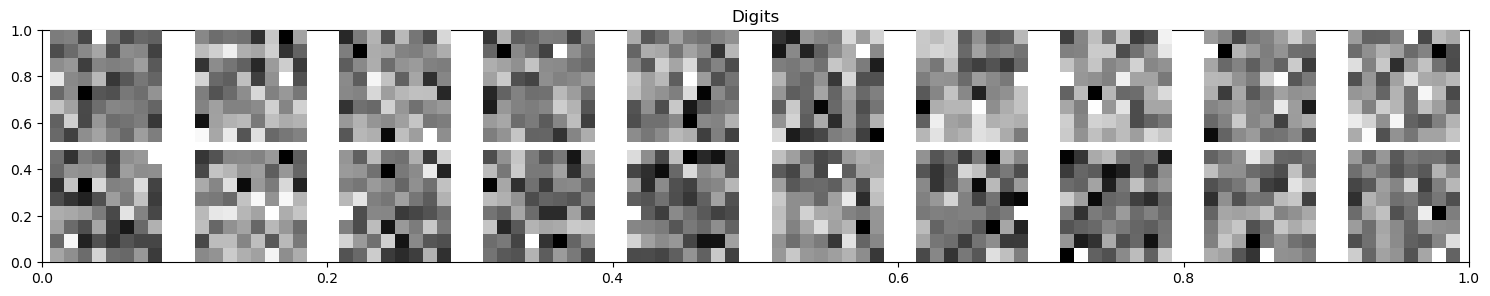

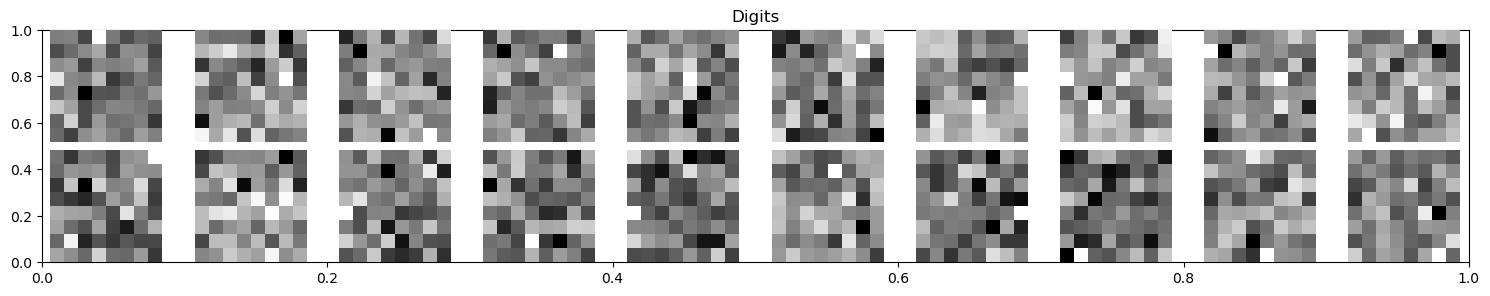

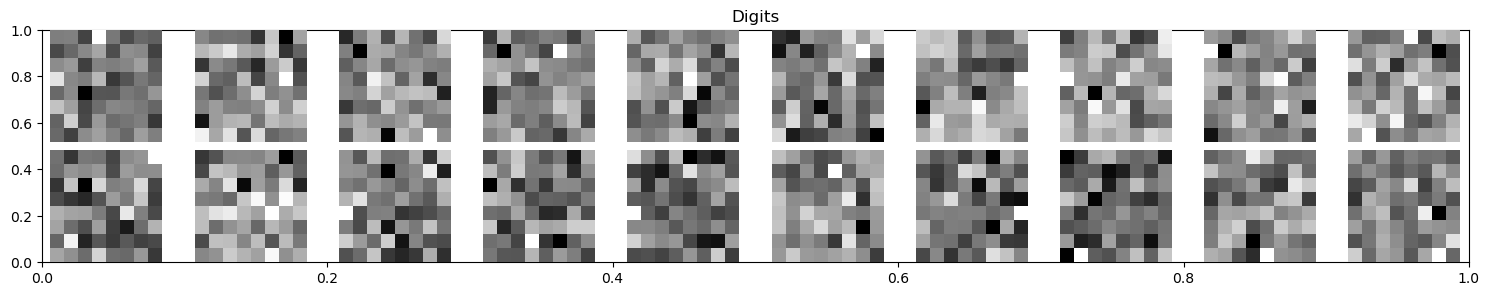

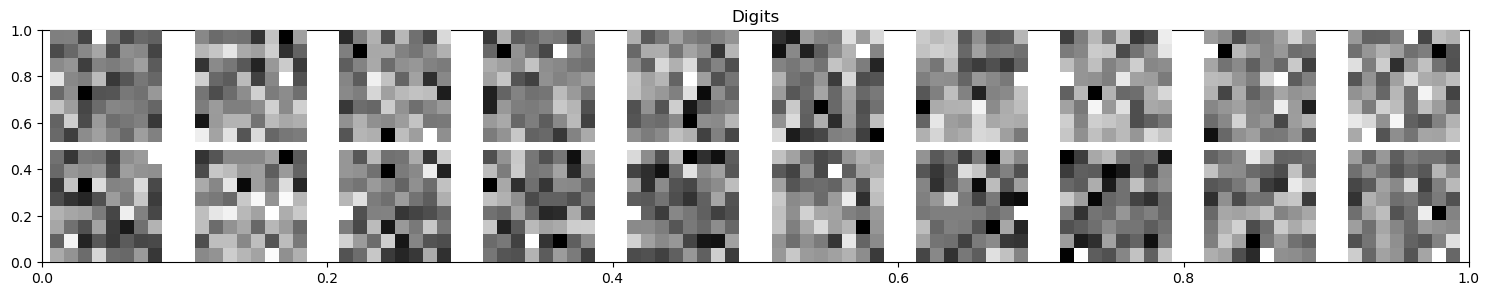

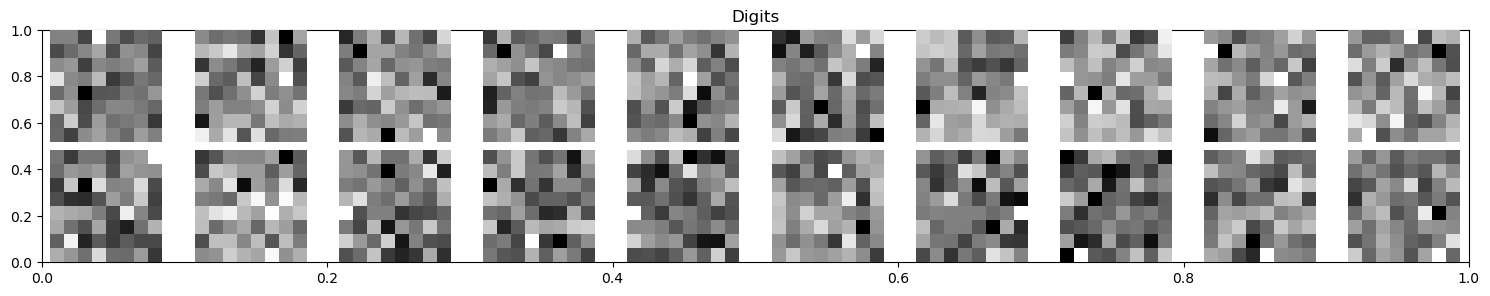

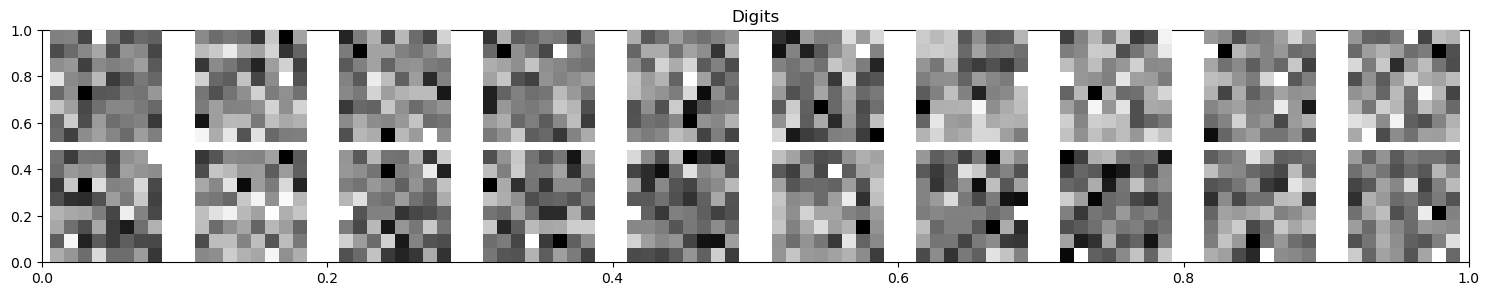

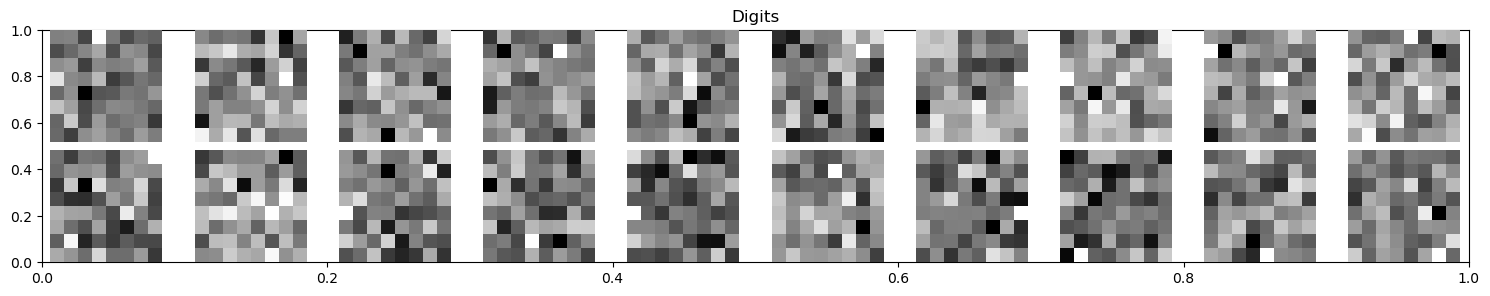

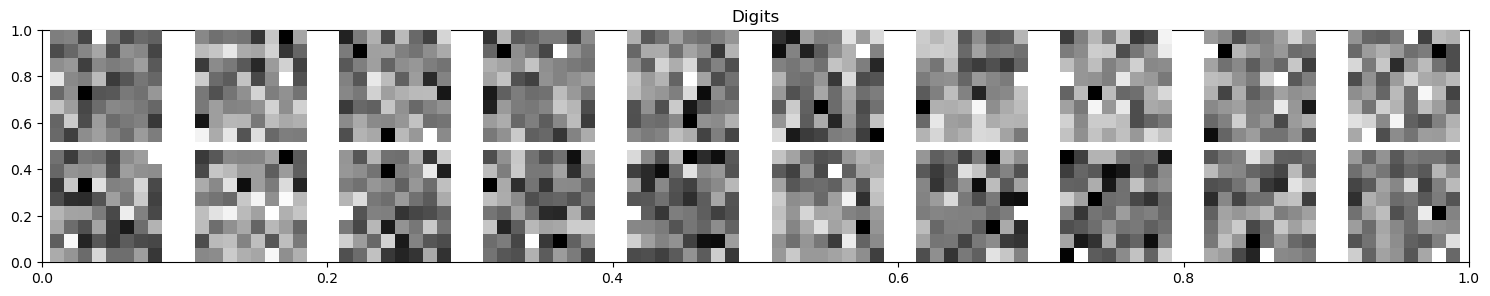

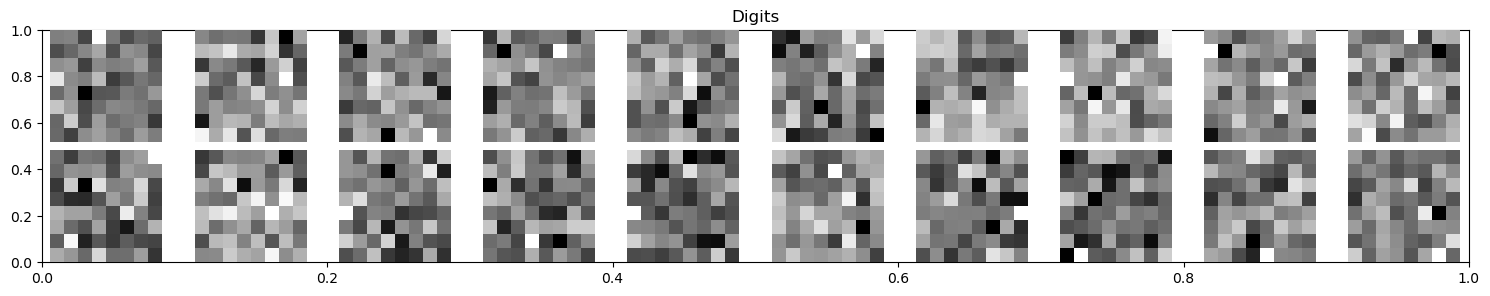

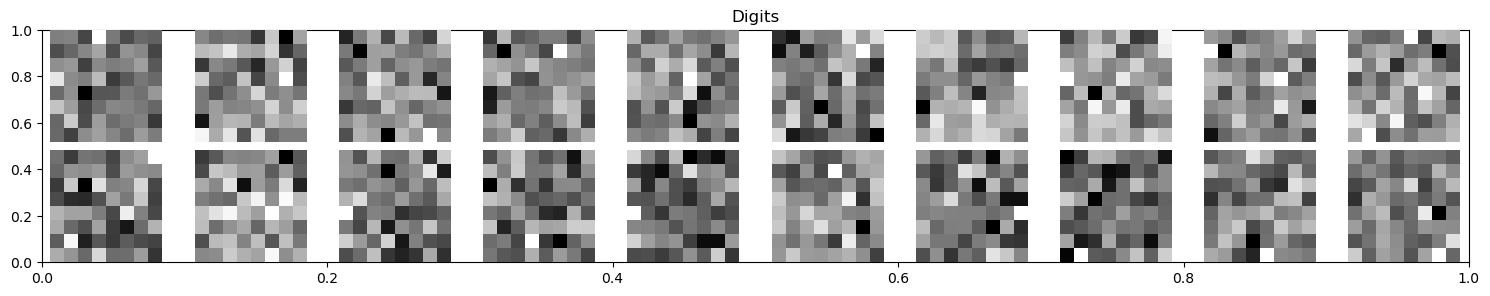

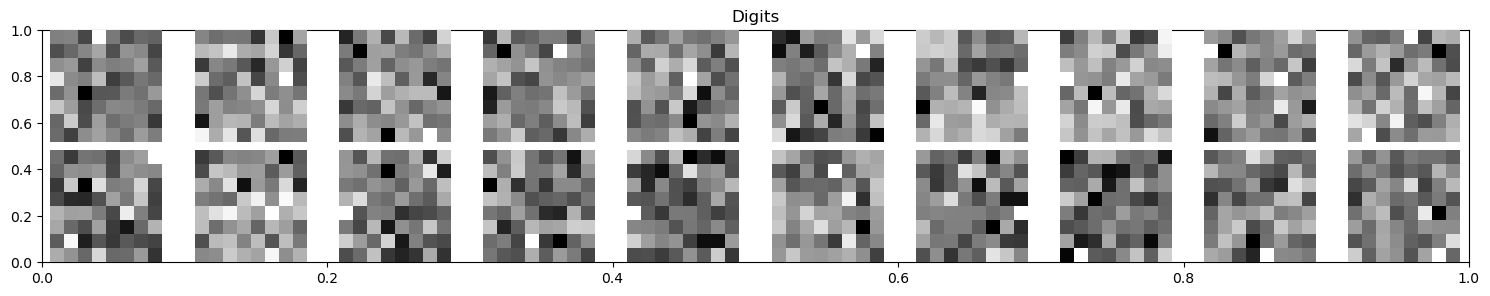

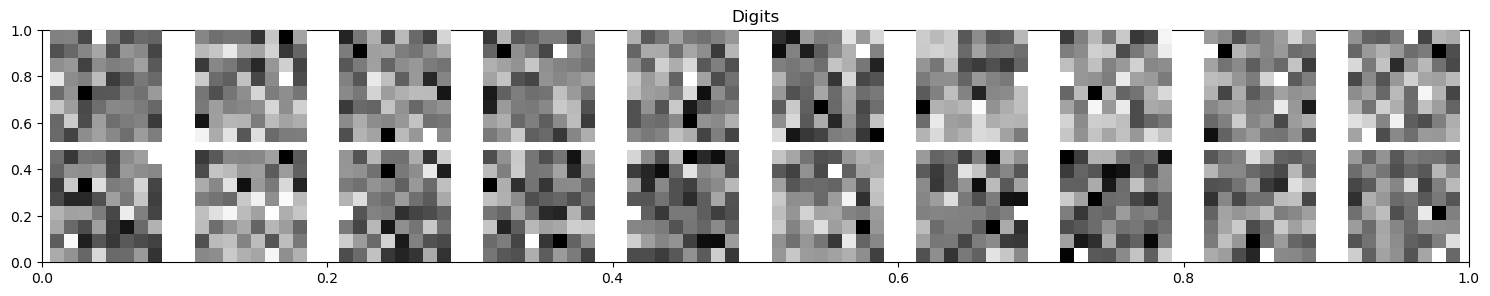

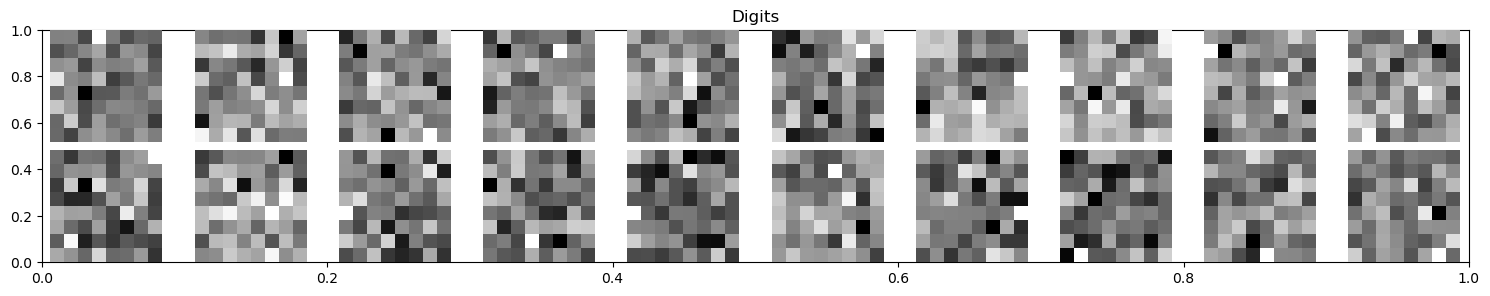

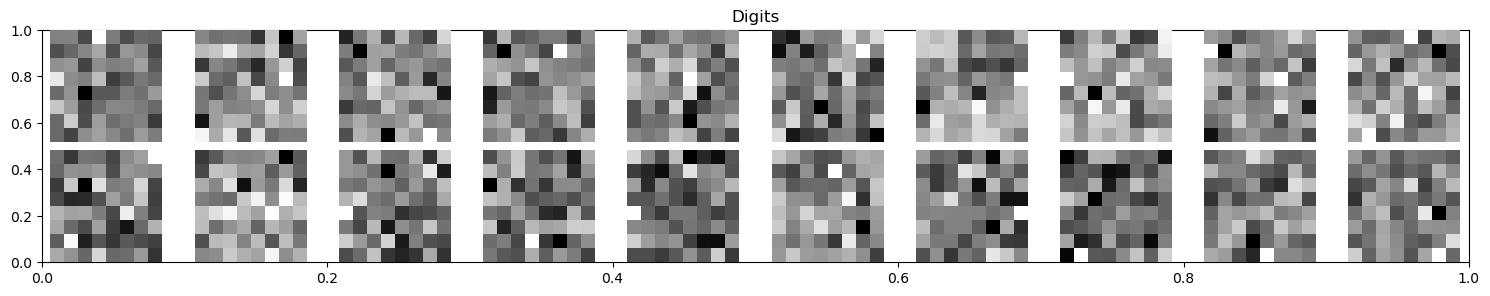

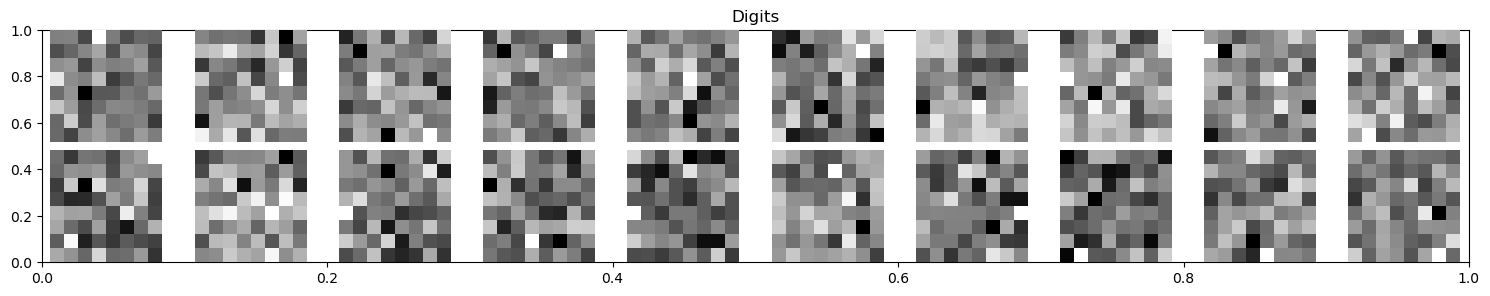

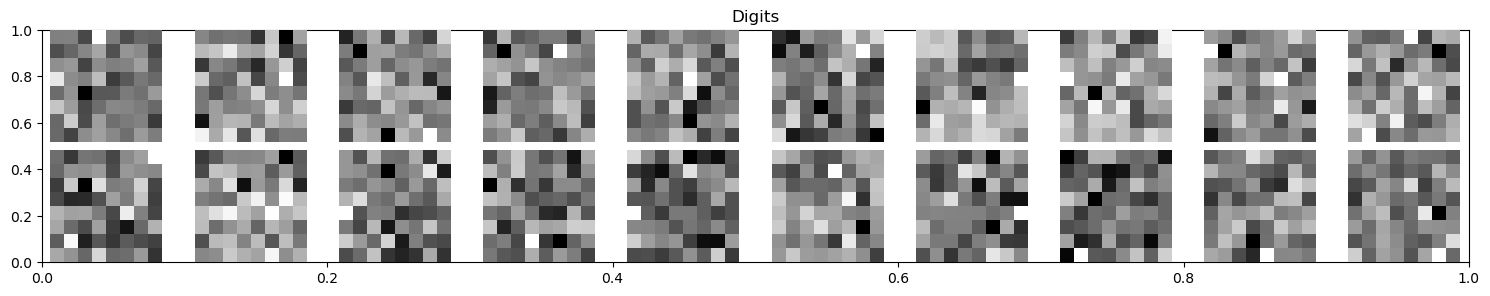

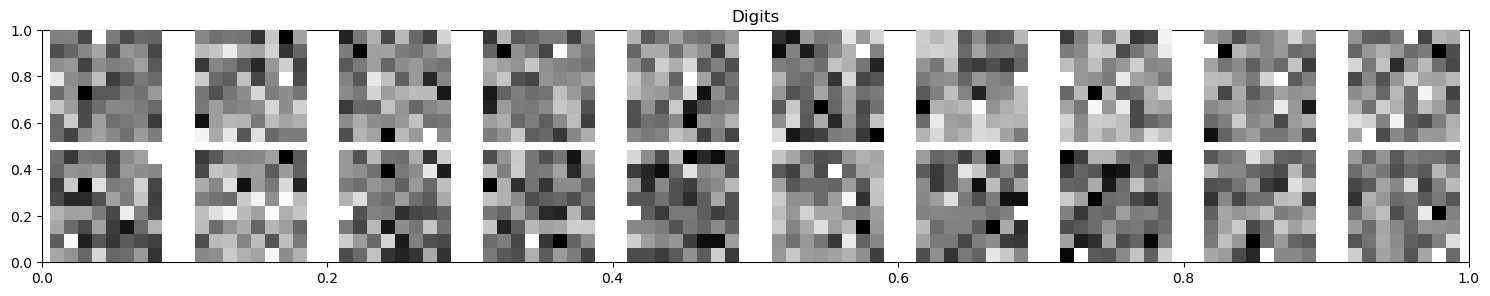

In [6]:
import sys
sys.path.append("../..")
from datasets.mpl2gif import figures_to_gif


L = 20
T = 100
eps = 2e-5

sigmas = sigmas_geometric(torch.linspace(1,0,L), sigma_min, sigma_max, var_schedule)
ncsm = torch.load("ncsm.ckpt", map_location="cuda:0")
ncsm.eval()

# dim=2
# num_samples = 1024
# x = torch.randn(size=(num_samples,2), device=device)
dim=(1,8,8)
num_samples = 20
x = torch.randn(size=(num_samples,*dim), device=device)
# x = x * sigma_max
x_change = torch.zeros_like(x)

figures = []

with torch.no_grad():
    
    for noise_level in range(0,L):
        
        alpha_i = eps * sigmas[noise_level]**2 / sigmas[0]**2
        
        for t in range(0,T):
            z_t = torch.randn(size=(num_samples,*dim), device=device)
            sigma_i = torch.ones(size=([num_samples]+[1]*len(dim)), device=device)*sigmas[noise_level] 
            x = x + alpha_i/2 * ncsm(x, sigma_i) + torch.sqrt(alpha_i) * z_t
            x_change += alpha_i/2 * ncsm(x, sigma_i) + torch.sqrt(alpha_i) * z_t
        

        figures.append(plot_digits(x))
        # plot.close()
        # figures.append(plot_digits(x))


    figures_to_gif(figures)


        # plt.figure()
        # plt.scatter(*(x.T.cpu()), s=5, alpha=0.5) #  cmap=cmap_orange_red, 
        # plt.axis('equal')
        # plt.show()
        # plt.close()